In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

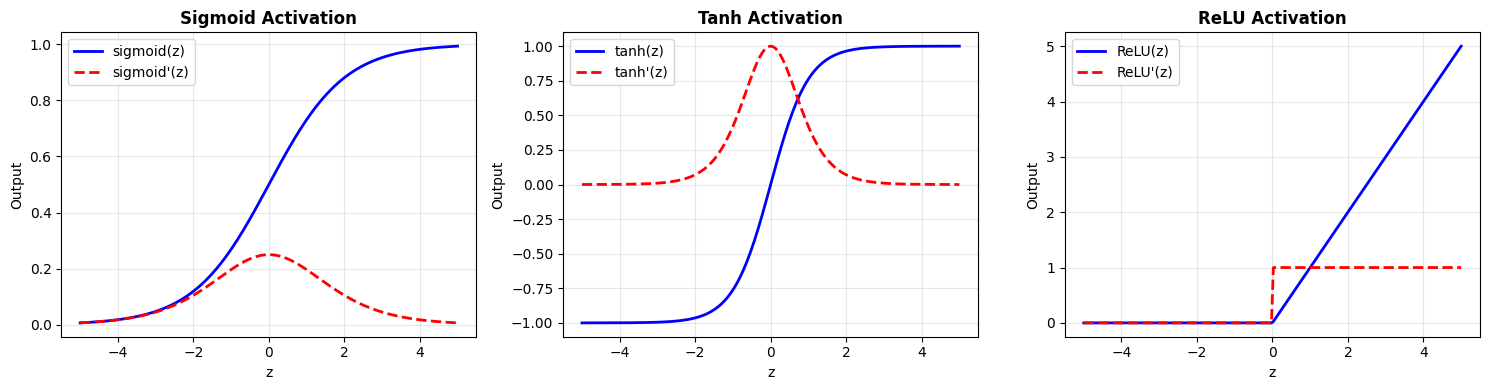

In [2]:
class ActivationFunctions:
    """
    Collection of activation functions and their derivatives
    """
    
    @staticmethod
    def sigmoid(z):
        """Sigmoid: σ(z) = 1 / (1 + e^(-z))"""
        return 1.0 / (1.0 + torch.exp(-z))
    
    @staticmethod
    def sigmoid_derivative(z):
        """Derivative: σ'(z) = σ(z) * (1 - σ(z))"""
        sig = ActivationFunctions.sigmoid(z)
        return sig * (1.0 - sig)
    
    @staticmethod
    def tanh(z):
        """Tanh: tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))"""
        return torch.tanh(z)
    
    @staticmethod
    def tanh_derivative(z):
        """Derivative: tanh'(z) = 1 - tanh²(z)"""
        return 1.0 - torch.tanh(z) ** 2
    
    @staticmethod
    def relu(z):
        """ReLU: max(0, z)"""
        return torch.maximum(torch.zeros_like(z), z)
    
    @staticmethod
    def relu_derivative(z):
        """Derivative: 1 if z > 0, else 0"""
        return torch.where(z > 0, torch.ones_like(z), torch.zeros_like(z))

# Visualize activation functions
z = torch.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sigmoid
axes[0].plot(z, ActivationFunctions.sigmoid(z), 'b-', linewidth=2, label='sigmoid(z)')
axes[0].plot(z, ActivationFunctions.sigmoid_derivative(z), 'r--', linewidth=2, label="sigmoid'(z)")
axes[0].set_title('Sigmoid Activation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('z')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Tanh
axes[1].plot(z, ActivationFunctions.tanh(z), 'b-', linewidth=2, label='tanh(z)')
axes[1].plot(z, ActivationFunctions.tanh_derivative(z), 'r--', linewidth=2, label="tanh'(z)")
axes[1].set_title('Tanh Activation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('z')
axes[1].set_ylabel('Output')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ReLU
axes[2].plot(z, ActivationFunctions.relu(z), 'b-', linewidth=2, label='ReLU(z)')
axes[2].plot(z, ActivationFunctions.relu_derivative(z), 'r--', linewidth=2, label="ReLU'(z)")
axes[2].set_title('ReLU Activation', fontsize=12, fontweight='bold')
axes[2].set_xlabel('z')
axes[2].set_ylabel('Output')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Generate non-linearly separable data (circles)
def generate_circle_data(n_samples=200, noise=0.1):
    """
    Generate data with two concentric circles
    """
    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out
    
    # Outer circle (class 0)
    angles_out = torch.rand(n_samples_out) * 2 * np.pi
    radius_out = torch.rand(n_samples_out) * 0.3 + 1.5
    x_out = radius_out * torch.cos(angles_out) + torch.randn(n_samples_out) * noise
    y_out = radius_out * torch.sin(angles_out) + torch.randn(n_samples_out) * noise
    outer = torch.stack([x_out, y_out], dim=1)
    labels_out = torch.zeros(n_samples_out, dtype=torch.long)
    
    # Inner circle (class 1)
    angles_in = torch.rand(n_samples_in) * 2 * np.pi
    radius_in = torch.rand(n_samples_in) * 0.7
    x_in = radius_in * torch.cos(angles_in) + torch.randn(n_samples_in) * noise
    y_in = radius_in * torch.sin(angles_in) + torch.randn(n_samples_in) * noise
    inner = torch.stack([x_in, y_in], dim=1)
    labels_in = torch.ones(n_samples_in, dtype=torch.long)
    
    # Combine
    X = torch.cat([outer, inner], dim=0)
    y = torch.cat([labels_out, labels_in], dim=0)
    
    # Shuffle
    indices = torch.randperm(n_samples)
    X = X[indices]
    y = y[indices]
    
    return X, y

# Generate data
X, y = generate_circle_data(n_samples=200, noise=0.1)
print(f"Data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Class distribution: Class 0: {(y == 0).sum().item()}, Class 1: {(y == 1).sum().item()}")

Data shape: torch.Size([200, 2])
Labels shape: torch.Size([200])
Class distribution: Class 0: 100, Class 1: 100


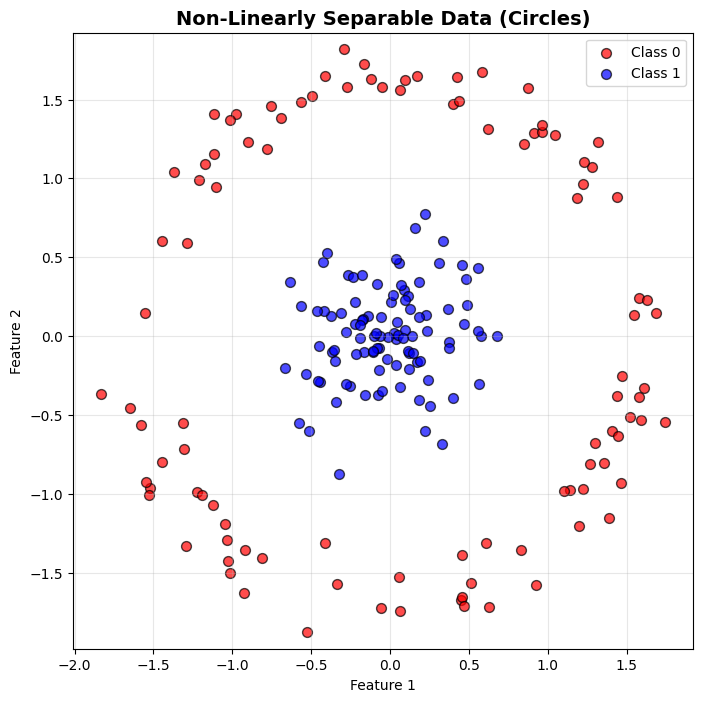

This data cannot be separated by a single straight line!
A multilayer network is needed.


In [4]:
# Visualize the data
plt.figure(figsize=(8, 8))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', s=50, alpha=0.7, edgecolors='black')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', s=50, alpha=0.7, edgecolors='black')
plt.title('Non-Linearly Separable Data (Circles)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print("This data cannot be separated by a single straight line!")
print("A multilayer network is needed.")

In [5]:
class MultilayerNeuralNetwork:
    def __init__(self, layer_sizes, activation='sigmoid', learning_rate=0.1):
        """
        Multilayer Neural Network with backpropagation
        
        Parameters:
        -----------
        layer_sizes : list
            List of layer sizes [input_size, hidden1_size, ..., output_size]
            Example: [2, 4, 3, 1] means 2 inputs, 2 hidden layers (4 and 3 neurons), 1 output
        activation : str
            Activation function: 'sigmoid', 'tanh', or 'relu'
        learning_rate : float
            Learning rate for gradient descent
        """
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes)
        self.learning_rate = learning_rate
        self.activation_name = activation
        
        # Set activation functions
        if activation == 'sigmoid':
            self.activation = ActivationFunctions.sigmoid
            self.activation_derivative = ActivationFunctions.sigmoid_derivative
        elif activation == 'tanh':
            self.activation = ActivationFunctions.tanh
            self.activation_derivative = ActivationFunctions.tanh_derivative
        elif activation == 'relu':
            self.activation = ActivationFunctions.relu
            self.activation_derivative = ActivationFunctions.relu_derivative
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        # Initialize weights and biases
        self.weights = []
        self.biases = []
        
        # Xavier/He initialization
        for i in range(self.n_layers - 1):
            # Xavier initialization: weights ~ U(-sqrt(6/(n_in + n_out)), sqrt(6/(n_in + n_out)))
            limit = np.sqrt(6.0 / (layer_sizes[i] + layer_sizes[i+1]))
            w = torch.rand(layer_sizes[i], layer_sizes[i+1]) * 2 * limit - limit
            b = torch.zeros(layer_sizes[i+1])
            
            self.weights.append(w)
            self.biases.append(b)
        
        # Store activations and z values for backprop
        self.activations = []
        self.z_values = []
        
        # Training history
        self.loss_history = []
        
    def forward(self, X):
        """
        Forward propagation
        
        Parameters:
        -----------
        X : torch.Tensor
            Input data of shape (n_samples, n_features) or (n_features,)
        
        Returns:
        --------
        output : torch.Tensor
            Network output
        """
        # Handle single sample or batch
        if X.dim() == 1:
            X = X.unsqueeze(0)
        
        # Clear previous activations
        self.activations = [X]
        self.z_values = []
        
        # Forward through layers
        current_activation = X
        
        for i in range(self.n_layers - 1):
            # Compute z = W^T * a + b
            z = current_activation @ self.weights[i] + self.biases[i]
            self.z_values.append(z)
            
            # Apply activation (use sigmoid for output layer in binary classification)
            if i == self.n_layers - 2:  # Output layer
                current_activation = ActivationFunctions.sigmoid(z)
            else:  # Hidden layers
                current_activation = self.activation(z)
            
            self.activations.append(current_activation)
        
        return current_activation
    
    def backward(self, X, y, output):
        """
        Backpropagation - compute gradients
        
        Parameters:
        -----------
        X : torch.Tensor
            Input data
        y : torch.Tensor
            True labels
        output : torch.Tensor
            Network output from forward pass
        """
        if X.dim() == 1:
            X = X.unsqueeze(0)
        if y.dim() == 0:
            y = y.unsqueeze(0)
        if output.dim() == 1:
            output = output.unsqueeze(0)
        
        n_samples = X.shape[0]
        
        # Initialize gradients
        weight_gradients = [torch.zeros_like(w) for w in self.weights]
        bias_gradients = [torch.zeros_like(b) for b in self.biases]
        
        # Output layer error (delta)
        # For binary cross-entropy with sigmoid: delta = (output - y)
        delta = output - y.unsqueeze(1).float()
        
        # Backpropagate through layers
        for i in range(self.n_layers - 2, -1, -1):
            # Compute gradients for this layer
            weight_gradients[i] = self.activations[i].T @ delta / n_samples
            bias_gradients[i] = delta.mean(dim=0)
            
            # Propagate error to previous layer (if not input layer)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.activation_derivative(self.z_values[i-1])
        
        # Update weights and biases using gradient descent
        for i in range(self.n_layers - 1):
            self.weights[i] -= self.learning_rate * weight_gradients[i]
            self.biases[i] -= self.learning_rate * bias_gradients[i]
    
    def compute_loss(self, output, y):
        """
        Compute binary cross-entropy loss
        
        Loss = -[y*log(ŷ) + (1-y)*log(1-ŷ)]
        """
        if output.dim() == 1:
            output = output.unsqueeze(0)
        if y.dim() == 0:
            y = y.unsqueeze(0)
        
        y = y.unsqueeze(1).float()
        epsilon = 1e-10  # For numerical stability
        loss = -torch.mean(y * torch.log(output + epsilon) + (1 - y) * torch.log(1 - output + epsilon))
        return loss.item()
    
    def fit(self, X, y, epochs=1000, verbose=True):
        """
        Train the network
        
        Parameters:
        -----------
        X : torch.Tensor
            Training data of shape (n_samples, n_features)
        y : torch.Tensor
            Labels of shape (n_samples,)
        epochs : int
            Number of training epochs
        verbose : bool
            Print training progress
        """
        if verbose:
            print(f"Training Neural Network")
            print(f"Architecture: {self.layer_sizes}")
            print(f"Activation: {self.activation_name}")
            print(f"Learning rate: {self.learning_rate}")
            print(f"Epochs: {epochs}\n")
        
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(output, y)
            self.loss_history.append(loss)
            
            # Backward pass
            self.backward(X, y, output)
            
            # Print progress
            if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
                accuracy = self.score(X, y)
                print(f"Epoch {epoch:4d}: Loss = {loss:.4f}, Accuracy = {accuracy*100:.2f}%")
        
        if verbose:
            print("\nTraining completed!")
        
        return self
    
    def predict_proba(self, X):
        """
        Predict probabilities
        """
        output = self.forward(X)
        return output.squeeze()
    
    def predict(self, X):
        """
        Predict class labels
        """
        probs = self.predict_proba(X)
        return (probs >= 0.5).long()
    
    def score(self, X, y):
        """
        Compute accuracy
        """
        predictions = self.predict(X)
        accuracy = (predictions == y).float().mean().item()
        return accuracy

In [6]:
# Create and train neural network
# Architecture: 2 inputs -> 8 hidden neurons -> 4 hidden neurons -> 1 output
mlp = MultilayerNeuralNetwork(
    layer_sizes=[2, 8, 4, 1],
    activation='tanh',
    learning_rate=0.5
)

mlp.fit(X, y, epochs=1000, verbose=True)

Training Neural Network
Architecture: [2, 8, 4, 1]
Activation: tanh
Learning rate: 0.5
Epochs: 1000

Epoch    0: Loss = 0.6977, Accuracy = 63.50%
Epoch  100: Loss = 0.0899, Accuracy = 100.00%
Epoch  200: Loss = 0.0344, Accuracy = 100.00%
Epoch  300: Loss = 0.0206, Accuracy = 100.00%
Epoch  400: Loss = 0.0146, Accuracy = 100.00%
Epoch  500: Loss = 0.0112, Accuracy = 100.00%
Epoch  600: Loss = 0.0091, Accuracy = 100.00%
Epoch  700: Loss = 0.0077, Accuracy = 100.00%
Epoch  800: Loss = 0.0066, Accuracy = 100.00%
Epoch  900: Loss = 0.0058, Accuracy = 100.00%
Epoch  999: Loss = 0.0051, Accuracy = 100.00%

Training completed!


In [7]:
# Evaluate on training data
predictions = mlp.predict(X)
accuracy = mlp.score(X, y)

print(f"\nFinal Training Accuracy: {accuracy * 100:.2f}%")
print(f"Correctly classified: {(predictions == y).sum().item()} / {len(y)}")
print(f"Misclassified: {(predictions != y).sum().item()} / {len(y)}")


Final Training Accuracy: 100.00%
Correctly classified: 200 / 200
Misclassified: 0 / 200


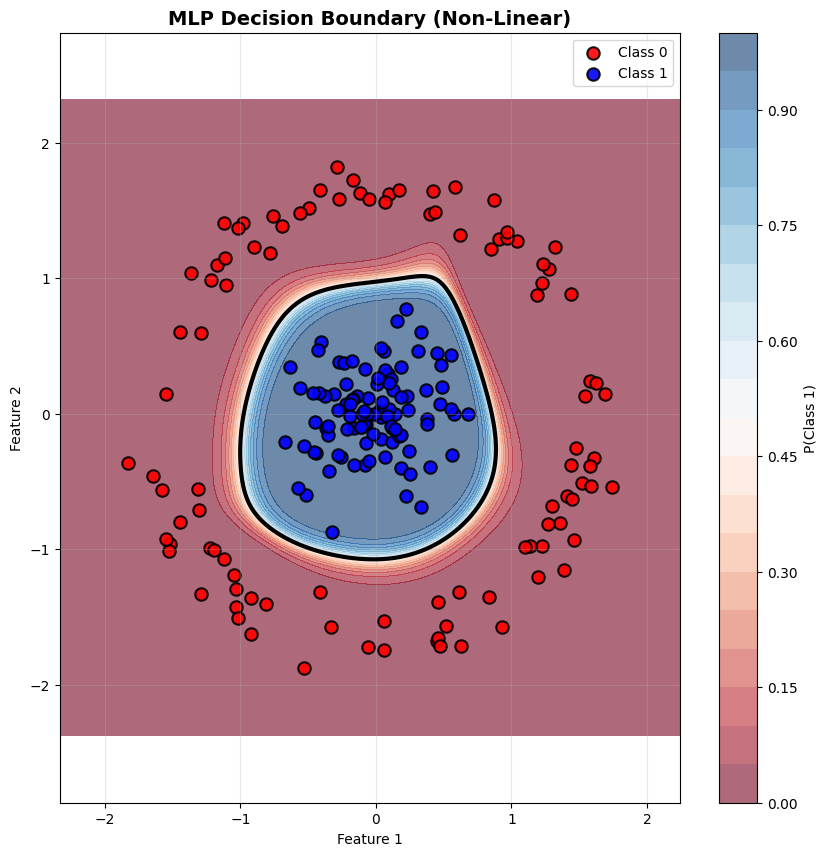

In [8]:
def plot_mlp_decision_boundary(X, y, model, title="MLP Decision Boundary"):
    """
    Plot decision boundary for MLP
    """
    plt.figure(figsize=(10, 10))
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict on mesh grid
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = model.predict_proba(grid_points)
    Z = Z.reshape(xx.shape).detach().numpy()
    
    # Plot decision boundary with probability contours
    contour = plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
    plt.colorbar(contour, label='P(Class 1)')
    
    # Plot decision boundary at 0.5
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=3)
    
    # Plot data points
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', 
                s=80, alpha=0.9, edgecolors='black', linewidths=1.5)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', 
                s=80, alpha=0.9, edgecolors='black', linewidths=1.5)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# Plot decision boundary
plot_mlp_decision_boundary(X, y, mlp, "MLP Decision Boundary (Non-Linear)")

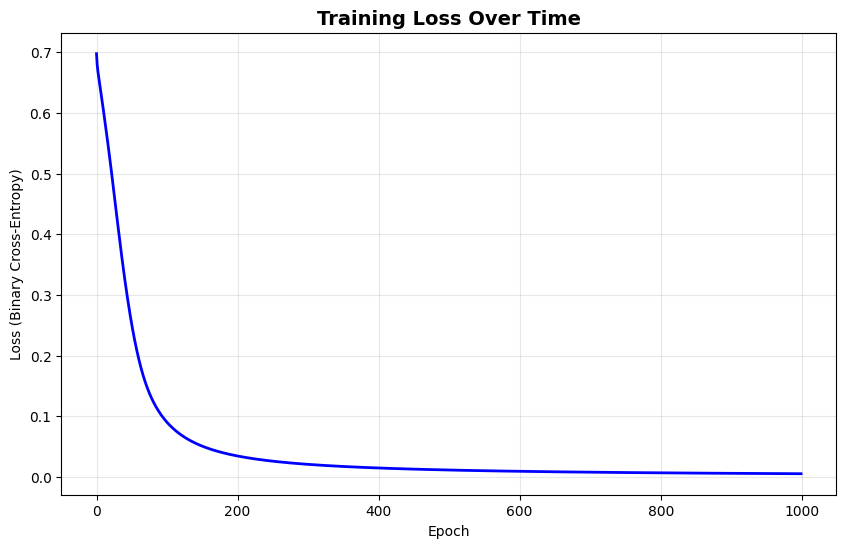

Initial loss: 0.6977
Final loss: 0.0051
Loss reduction: 99.26%


In [9]:
# Plot loss curve
plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_history, 'b-', linewidth=2)
plt.title('Training Loss Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial loss: {mlp.loss_history[0]:.4f}")
print(f"Final loss: {mlp.loss_history[-1]:.4f}")
print(f"Loss reduction: {(1 - mlp.loss_history[-1]/mlp.loss_history[0])*100:.2f}%")

In [10]:
print("=" * 60)
print("XOR PROBLEM - Solved with MLP!")
print("=" * 60)

# XOR data
X_xor = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y_xor = torch.tensor([0, 1, 1, 0])

print(f"\nXOR Truth Table:")
print(f"{'X1':<6} {'X2':<6} {'Output'}")
print("-" * 20)
for i in range(len(X_xor)):
    print(f"{X_xor[i, 0].item():<6.0f} {X_xor[i, 1].item():<6.0f} {y_xor[i].item()}")

print("\n" + "=" * 60)
print("Training MLP on XOR...")
print("=" * 60 + "\n")

# Create MLP for XOR: 2 inputs -> 4 hidden -> 1 output
mlp_xor = MultilayerNeuralNetwork(
    layer_sizes=[2, 4, 1],
    activation='tanh',
    learning_rate=0.5
)

mlp_xor.fit(X_xor, y_xor, epochs=2000, verbose=True)

XOR PROBLEM - Solved with MLP!

XOR Truth Table:
X1     X2     Output
--------------------
0      0      0
0      1      1
1      0      1
1      1      0

Training MLP on XOR...

Training Neural Network
Architecture: [2, 4, 1]
Activation: tanh
Learning rate: 0.5
Epochs: 2000

Epoch    0: Loss = 0.7537, Accuracy = 50.00%
Epoch  100: Loss = 0.1234, Accuracy = 100.00%
Epoch  200: Loss = 0.0365, Accuracy = 100.00%
Epoch  300: Loss = 0.0204, Accuracy = 100.00%
Epoch  400: Loss = 0.0140, Accuracy = 100.00%
Epoch  500: Loss = 0.0106, Accuracy = 100.00%
Epoch  600: Loss = 0.0085, Accuracy = 100.00%
Epoch  700: Loss = 0.0071, Accuracy = 100.00%
Epoch  800: Loss = 0.0061, Accuracy = 100.00%
Epoch  900: Loss = 0.0053, Accuracy = 100.00%
Epoch 1000: Loss = 0.0047, Accuracy = 100.00%
Epoch 1100: Loss = 0.0042, Accuracy = 100.00%
Epoch 1200: Loss = 0.0039, Accuracy = 100.00%
Epoch 1300: Loss = 0.0035, Accuracy = 100.00%
Epoch 1400: Loss = 0.0033, Accuracy = 100.00%
Epoch 1500: Loss = 0.0030, Accura

In [11]:
# Evaluate XOR
predictions_xor = mlp_xor.predict(X_xor)
probabilities_xor = mlp_xor.predict_proba(X_xor)
accuracy_xor = mlp_xor.score(X_xor, y_xor)

print(f"\n" + "=" * 60)
print("XOR RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy_xor * 100:.2f}%\n")

print(f"{'Input':<15} {'Predicted':<12} {'Probability':<15} {'Actual':<10} {'Status'}")
print("=" * 60)
for i in range(len(X_xor)):
    inp = f"({X_xor[i, 0]:.0f}, {X_xor[i, 1]:.0f})"
    pred = predictions_xor[i].item()
    prob = probabilities_xor[i].item()
    actual = y_xor[i].item()
    status = "✓" if pred == actual else "✗"
    print(f"{inp:<15} {pred:<12} {prob:<15.4f} {actual:<10} {status}")

print("\n✓ MLP successfully solved XOR problem!")
print("This was impossible for a single-layer perceptron.")


XOR RESULTS
Accuracy: 100.00%

Input           Predicted    Probability     Actual     Status
(0, 0)          0            0.0004          0          ✓
(0, 1)          1            0.9970          1          ✓
(1, 0)          1            0.9977          1          ✓
(1, 1)          0            0.0031          0          ✓

✓ MLP successfully solved XOR problem!
This was impossible for a single-layer perceptron.


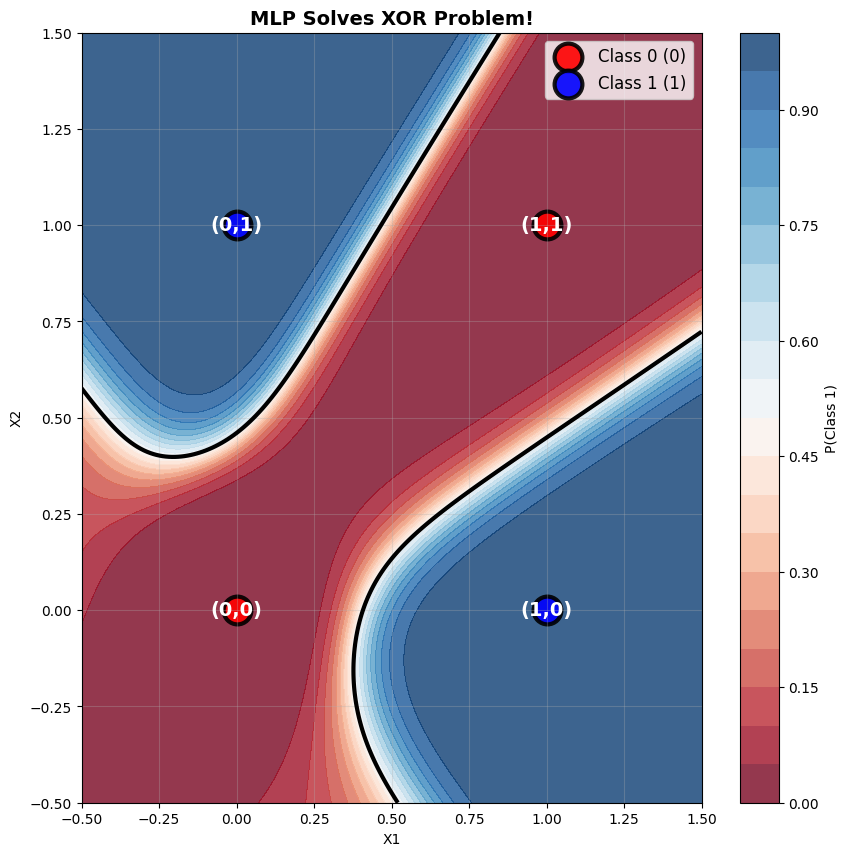

In [12]:
# Visualize XOR solution
plt.figure(figsize=(10, 10))

# Create mesh grid
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))

# Predict on mesh
grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
Z_xor = mlp_xor.predict_proba(grid_points)
Z_xor = Z_xor.reshape(xx.shape).detach().numpy()

# Plot
contour = plt.contourf(xx, yy, Z_xor, levels=20, cmap='RdBu', alpha=0.8)
plt.colorbar(contour, label='P(Class 1)')
plt.contour(xx, yy, Z_xor, levels=[0.5], colors='black', linewidths=3)

# Plot XOR points
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], 
           c='red', s=400, label='Class 0 (0)', alpha=0.9, edgecolors='black', linewidths=3)
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], 
           c='blue', s=400, label='Class 1 (1)', alpha=0.9, edgecolors='black', linewidths=3)

# Annotate
for i, point in enumerate(X_xor):
    plt.annotate(f'({point[0]:.0f},{point[1]:.0f})', 
                xy=point, xytext=(0, 0), textcoords='offset points',
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')

plt.title('MLP Solves XOR Problem!', fontsize=14, fontweight='bold')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()

Training Small (2 hidden)...
Training Medium (4 hidden)...
Training Large (8 hidden)...
Training Deep (8->4 hidden)...


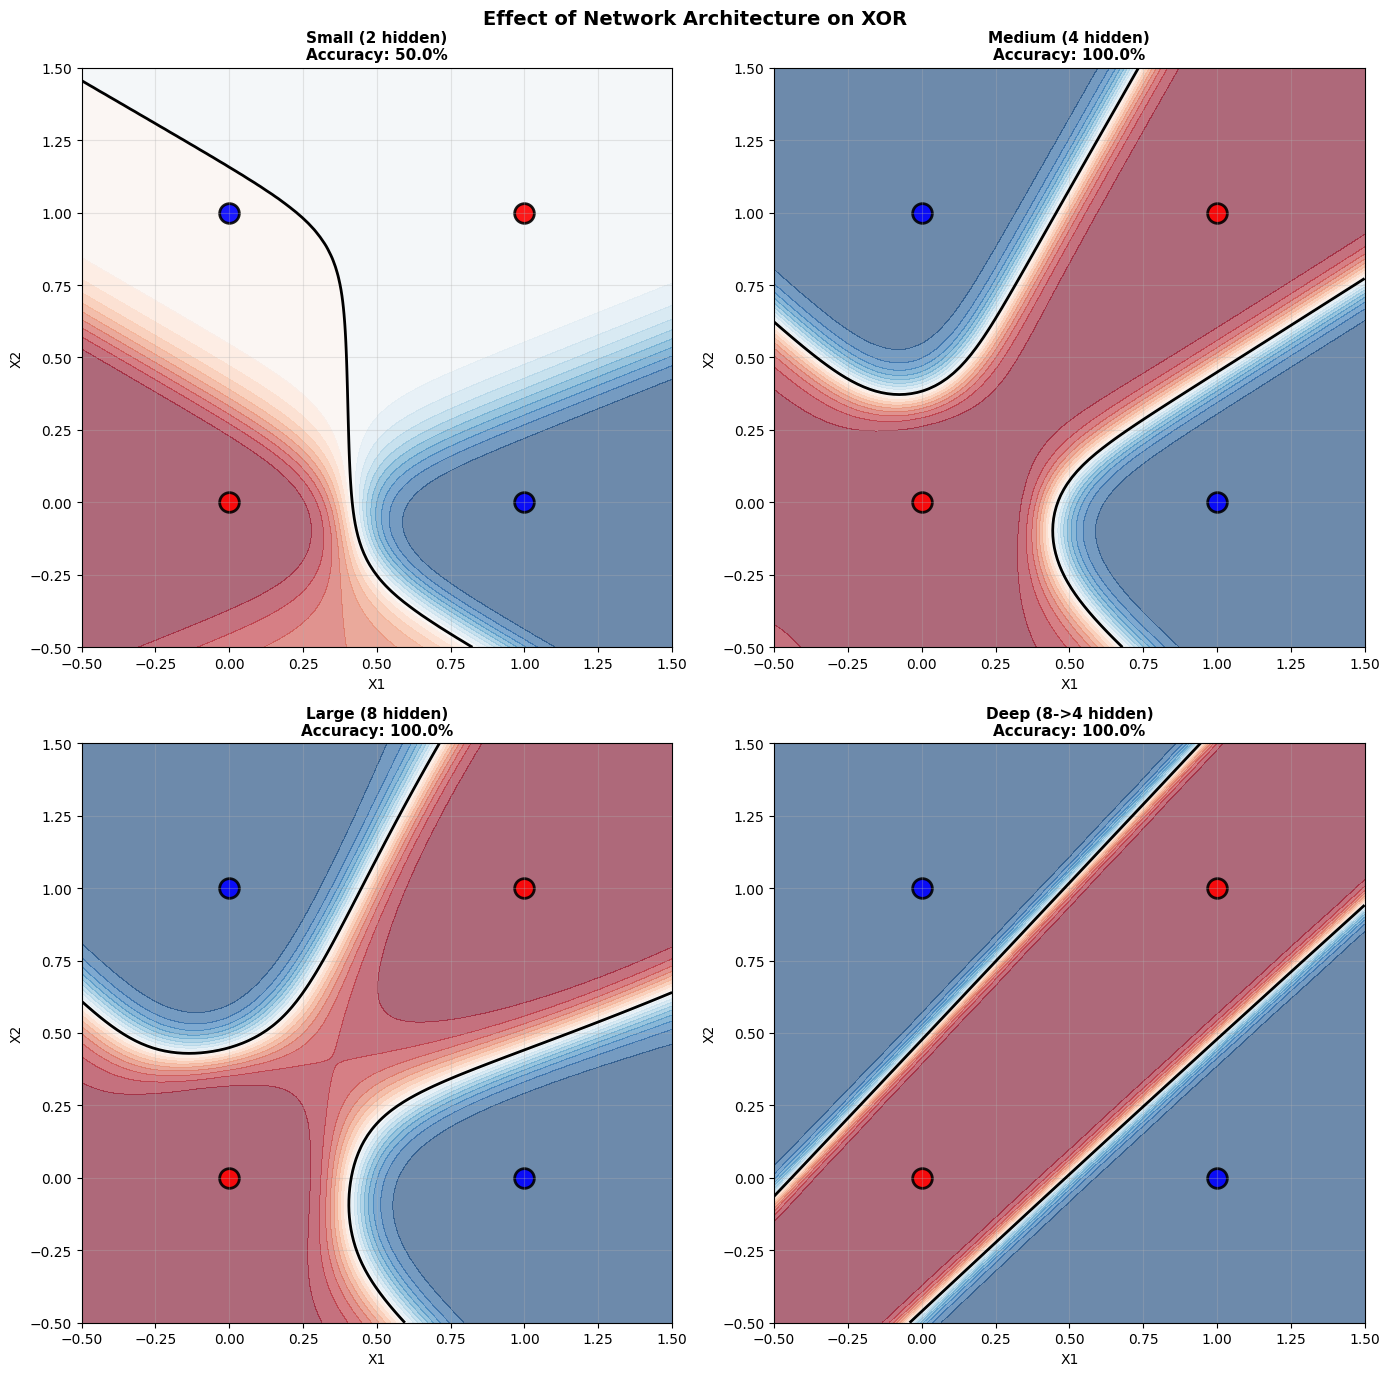


All architectures can solve XOR, but deeper/wider networks may be more robust.


In [13]:
# Compare different architectures
architectures = [
    ([2, 2, 1], "Small (2 hidden)"),
    ([2, 4, 1], "Medium (4 hidden)"),
    ([2, 8, 1], "Large (8 hidden)"),
    ([2, 8, 4, 1], "Deep (8->4 hidden)")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, (arch, name) in enumerate(architectures):
    print(f"Training {name}...")
    
    # Train model
    model = MultilayerNeuralNetwork(arch, activation='tanh', learning_rate=0.5)
    model.fit(X_xor, y_xor, epochs=2000, verbose=False)
    
    # Plot decision boundary
    ax = axes[idx]
    
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100),
                         np.linspace(-0.5, 1.5, 100))
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = model.predict_proba(grid_points).reshape(xx.shape).detach().numpy()
    
    contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], 
              c='red', s=200, alpha=0.9, edgecolors='black', linewidths=2)
    ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], 
              c='blue', s=200, alpha=0.9, edgecolors='black', linewidths=2)
    
    accuracy = model.score(X_xor, y_xor)
    ax.set_title(f'{name}\nAccuracy: {accuracy*100:.1f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

plt.suptitle('Effect of Network Architecture on XOR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAll architectures can solve XOR, but deeper/wider networks may be more robust.")

In [14]:
print("=" * 70)
print("SIMPLE FORWARD PASS EXAMPLE (Manual Calculation)")
print("=" * 70)

# Create simple network: 2 -> 2 -> 1
simple_mlp = MultilayerNeuralNetwork([2, 2, 1], activation='sigmoid', learning_rate=0.1)

# Set simple weights for demonstration
simple_mlp.weights[0] = torch.tensor([[0.5, -0.3], [0.2, 0.4]])
simple_mlp.biases[0] = torch.tensor([0.1, -0.2])
simple_mlp.weights[1] = torch.tensor([[0.6], [-0.4]])
simple_mlp.biases[1] = torch.tensor([0.3])

print("\nNetwork Architecture: 2 inputs -> 2 hidden -> 1 output")
print(f"\nWeights Layer 1 (Input -> Hidden):\n{simple_mlp.weights[0]}")
print(f"Biases Layer 1:\n{simple_mlp.biases[0]}")
print(f"\nWeights Layer 2 (Hidden -> Output):\n{simple_mlp.weights[1]}")
print(f"Biases Layer 2:\n{simple_mlp.biases[1]}")

# Test input
test_input = torch.tensor([1.0, 0.5])
print(f"\nInput: {test_input.tolist()}")

# Manual forward pass
print("\n" + "-" * 70)
print("FORWARD PASS:")
print("-" * 70)

# Layer 1: Input -> Hidden
z1 = test_input @ simple_mlp.weights[0] + simple_mlp.biases[0]
a1 = ActivationFunctions.sigmoid(z1)
print(f"\nHidden Layer:")
print(f"  z1 = X @ W1 + b1 = {z1.tolist()}")
print(f"  a1 = sigmoid(z1) = {a1.tolist()}")

# Layer 2: Hidden -> Output
z2 = a1 @ simple_mlp.weights[1] + simple_mlp.biases[1]
a2 = ActivationFunctions.sigmoid(z2)
print(f"\nOutput Layer:")
print(f"  z2 = a1 @ W2 + b2 = {z2.tolist()}")
print(f"  output = sigmoid(z2) = {a2.tolist()}")

# Verify with forward method
output_verify = simple_mlp.forward(test_input)
print(f"\nVerification (using forward method): {output_verify.tolist()}")
print(f"Match: {torch.allclose(a2, output_verify.squeeze())}")

SIMPLE FORWARD PASS EXAMPLE (Manual Calculation)

Network Architecture: 2 inputs -> 2 hidden -> 1 output

Weights Layer 1 (Input -> Hidden):
tensor([[ 0.5000, -0.3000],
        [ 0.2000,  0.4000]])
Biases Layer 1:
tensor([ 0.1000, -0.2000])

Weights Layer 2 (Hidden -> Output):
tensor([[ 0.6000],
        [-0.4000]])
Biases Layer 2:
tensor([0.3000])

Input: [1.0, 0.5]

----------------------------------------------------------------------
FORWARD PASS:
----------------------------------------------------------------------

Hidden Layer:
  z1 = X @ W1 + b1 = [0.7000000476837158, -0.30000001192092896]
  a1 = sigmoid(z1) = [0.6681877970695496, 0.4255574941635132]

Output Layer:
  z2 = a1 @ W2 + b2 = [0.5306897163391113]
  output = sigmoid(z2) = [0.629643976688385]

Verification (using forward method): [[0.629643976688385]]
Match: True
